# **Imports & Load**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Project Datasets/Mall Customers Dataset_cleaned.csv')
X_scaled = pd.read_csv('/content/drive/MyDrive/Project Datasets/Mall Customers Dataset_scaled.csv').values
feature_cols = ['Age', 'Income', 'SpendingScore', 'Gender_Male']
print('Shape:', df.shape, 'X_scaled:', X_scaled.shape)
df.head()

Mounted at /content/drive
Shape: (200, 5) X_scaled: (200, 4)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,1
1,2,21,15,81,1
2,3,20,16,6,0
3,4,23,16,77,0
4,5,31,17,40,0


# **Helper Function**

In [ ]:
def find_optimal_k(X, k_range):
    inertias = []
    silhouettes = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        if k > 1:
            silhouettes.append(silhouette_score(X, kmeans.labels_))
        else:
            silhouettes.append(np.nan)
    metrics_df = pd.DataFrame({"k": k_range, "inertia": inertias, "silhouette": silhouettes})
    return metrics_df

def plot_elbow(metrics_df, ax):
    ax.plot(metrics_df['k'], metrics_df['inertia'], marker='o')
    ax.set_title('Elbow Method for Optimal k')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Inertia')

def plot_silhouette(metrics_df, ax):
    ax.plot(metrics_df['k'], metrics_df['silhouette'], marker='o')
    ax.set_title('Silhouette Score for Optimal k')
    ax.set_xlabel('Number of clusters (k)')
    ax.set_ylabel('Silhouette Score')

def fit_kmeans(X, k):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    labels = km.labels_
    return km, labels

def cluster_summary(df, labels):
    df_temp = df.copy()
    df_temp['cluster'] = labels
    summary = df_temp.groupby('cluster').agg(
        Count=('CustomerID', 'size'),
        Age=('Age', 'mean'),
        Income=('Annual Income (k$)', 'mean'),
        SpendingScore=('Spending Score (1-100)', 'mean'),
        Gender_Male=('Gender_Male', 'mean')
    ).round(2)
    return summary

# **Choose K — Elbow + Silhouette**

In [ ]:
metrics_df = find_optimal_k(X_scaled, k_range=range(2, 11))
metrics_df.round(4)

,k,inertia,silhouette
0,2,588.8027,0.2518
1,3,476.7876,0.2595
2,4,388.7179,0.2984
3,5,331.3099,0.3041
4,6,276.4118,0.3311
5,7,236.2049,0.3574
6,8,199.7505,0.3880
7,9,174.2355,0.4031
8,10,152.0298,0.4208


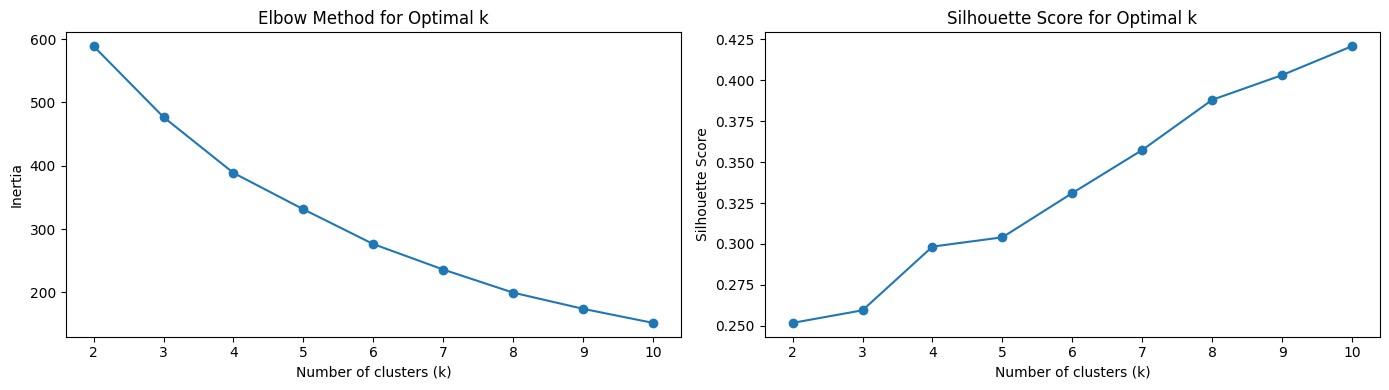

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_elbow(metrics_df, ax=axes[0])
plot_silhouette(metrics_df, ax=axes[1])
plt.tight_layout(); plt.show()

In [ ]:
best_k_silhouette = int(metrics_df.loc[metrics_df['silhouette'].idxmax(), 'k'])
print('Best k by silhouette:', best_k_silhouette)
best_k = best_k_silhouette  # use silhouette winner

Best k by silhouette: 10


# **Fit K-Means with the Chosen K**

In [ ]:
km, labels = fit_kmeans(X_scaled, best_k)
df_labelled = df.copy(); df_labelled['cluster'] = labels
print('Cluster sizes:'); print(df_labelled['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: count, dtype: int64


# **Visualize Clusters — Income vs SpendingScore**

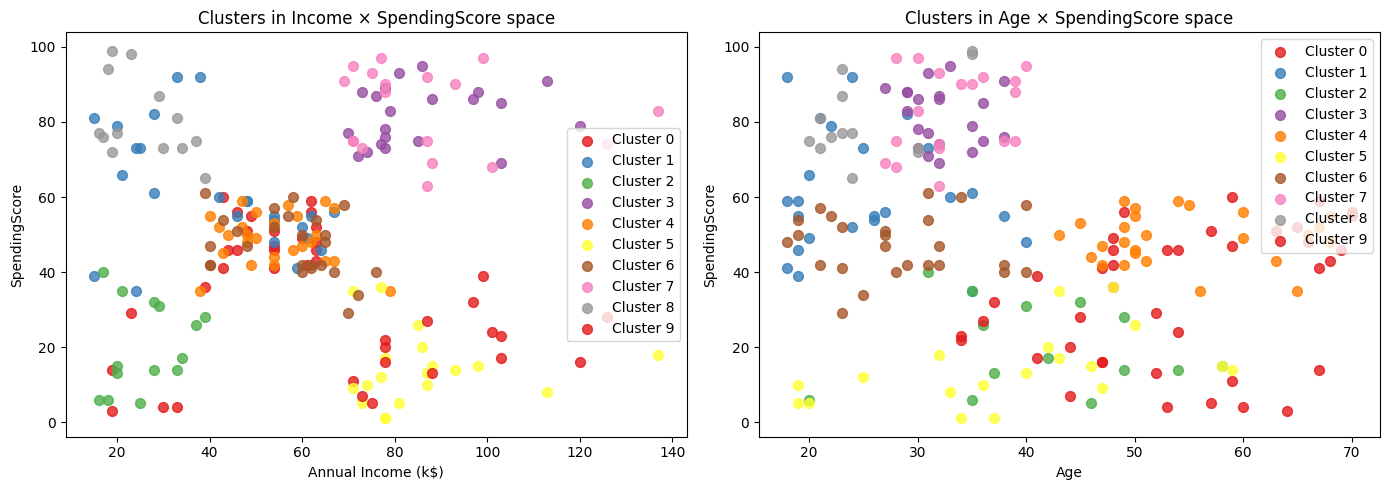

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette('Set1', best_k)
for c in range(best_k):
    sub = df_labelled[df_labelled['cluster'] == c]
    axes[0].scatter(sub['Annual Income (k$)'], sub['Spending Score (1-100)'], color=palette[c], label=f'Cluster {c}', alpha=0.8, s=50)
axes[0].set_xlabel('Annual Income (k$)'); axes[0].set_ylabel('SpendingScore')
axes[0].set_title('Clusters in Income × SpendingScore space'); axes[0].legend()
for c in range(best_k):
    sub = df_labelled[df_labelled['cluster'] == c]
    axes[1].scatter(sub['Age'], sub['Spending Score (1-100)'], color=palette[c], label=f'Cluster {c}', alpha=0.8, s=50)
axes[1].set_xlabel('Age'); axes[1].set_ylabel('SpendingScore')
axes[1].set_title('Clusters in Age × SpendingScore space'); axes[1].legend()
plt.tight_layout(); plt.show()

# **PCA — 2D View of Clusters**

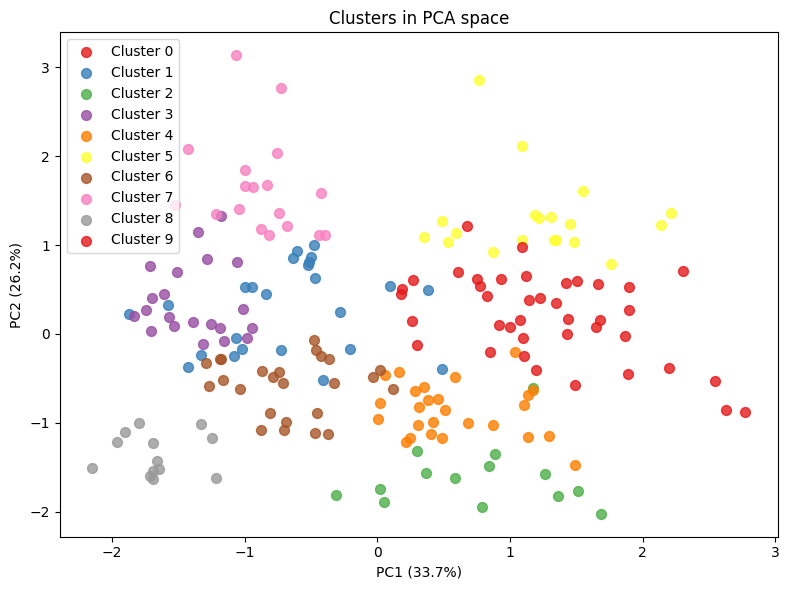

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
for c in range(best_k):
    mask = labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], color=palette[c], label=f'Cluster {c}', alpha=0.8, s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Clusters in PCA space'); ax.legend()
plt.tight_layout(); plt.show()

# **Cluster Profile Summary**

In [ ]:
summary = cluster_summary(df, labels)
summary

,Count,Age,Income,SpendingScore,Gender_Male
cluster,,,,,
0,26,58.85,48.69,39.85,1.00
1,24,25.25,41.25,60.92,1.00
2,14,41.21,26.07,20.14,0.07
3,21,32.19,86.05,81.67,0.00
4,26,54.15,54.23,48.96,0.00
5,19,38.47,85.89,14.21,1.00
6,25,27.96,57.36,47.12,0.00
7,18,33.28,87.11,82.67,1.00
8,13,25.46,25.69,80.54,0.00


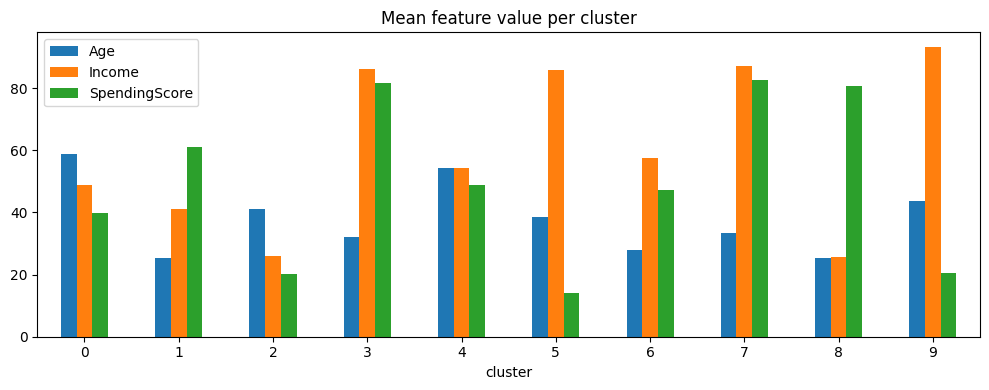

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
summary.drop(columns=['Count'])[['Age', 'Income', 'SpendingScore']].plot(kind='bar', ax=ax)
ax.set_title('Mean feature value per cluster')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# **Compare to Hierarchical Clustering**

In [ ]:
agg = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg.fit_predict(X_scaled)
print('Silhouette — KMeans     :', round(silhouette_score(X_scaled, labels), 4))
print('Silhouette — Hierarchical:', round(silhouette_score(X_scaled, agg_labels), 4))
ct = pd.crosstab(labels, agg_labels)
print('\nKMeans (rows) vs Hierarchical (cols) cluster overlap:')
ct

Silhouette — KMeans     : 0.4208
Silhouette — Hierarchical: 0.4176

KMeans (rows) vs Hierarchical (cols) cluster overlap:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,25,1,0,0,0,0,0,0,0,0
1,2,0,22,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,13
3,0,0,0,0,0,0,21,0,0,0
4,0,0,0,25,0,0,0,1,0,0
5,2,17,0,0,0,0,0,0,0,0
6,0,0,0,0,25,0,0,0,0,0
7,0,0,0,0,0,18,0,0,0,0
8,0,0,0,0,0,0,0,0,13,0


# **Cluster Naming & Marketing Personas**

In [ ]:
personas = []
for c in range(best_k):
    mean_inc = summary.loc[c, 'Income']
    mean_score = summary.loc[c, 'SpendingScore']
    mean_age = summary.loc[c, 'Age']
    if mean_inc > 60 and mean_score > 60: name = 'Target — high income, high spend'
    elif mean_inc > 60 and mean_score < 40: name = 'Cautious — high income, low spend'
    elif mean_inc < 40 and mean_score > 60: name = 'Impulsive — low income, high spend'
    elif mean_inc < 40 and mean_score < 40: name = 'Frugal — low income, low spend'
    else: name = 'Average shopper'
    personas.append({'cluster': c, 'persona': name,
                     'avg_age': mean_age, 'avg_income': mean_inc,
                     'avg_spending': mean_score, 'count': summary.loc[c, 'Count']})
personas_df = pd.DataFrame(personas)
personas_df

,cluster,persona,avg_age,avg_income,avg_spending,count
0,0,Average shopper,58.85,48.69,39.85,26
1,1,Average shopper,25.25,41.25,60.92,24
2,2,"Frugal — low income, low spend",41.21,26.07,20.14,14
3,3,"Target — high income, high spend",32.19,86.05,81.67,21
4,4,Average shopper,54.15,54.23,48.96,26
5,5,"Cautious — high income, low spend",38.47,85.89,14.21,19
6,6,Average shopper,27.96,57.36,47.12,25
7,7,"Target — high income, high spend",33.28,87.11,82.67,18
8,8,"Impulsive — low income, high spend",25.46,25.69,80.54,13
9,9,"Cautious — high income, low spend",43.79,93.29,20.64,14


# **Key Takeaways**

- K-Means with k chosen by silhouette identifies clear, interpretable customer segments.
- Income × SpendingScore is the dominant axis; age and gender are secondary.
- The **high-income / high-spend** segment is the prime marketing target.
- The **high-income / low-spend** segment may be persuadable with the right offer — they have the means but choose not to.
- Hierarchical clustering produces similar segments, which raises confidence that the partition is real.